In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
insurance=pd.read_csv("C:/Users/user/Downloads/insurance.csv")

In [3]:
print (insurance)

    age  weight  height  income_lpa  smoker       city      occupation  \
0    67   119.8    1.56     2.92000   False     Jaipur         retired   
1    36   101.1    1.83    34.28000   False    Chennai      freelancer   
2    39    56.8    1.64    36.64000   False     Indore      freelancer   
3    22   109.4    1.55     3.34000    True     Mumbai         student   
4    69    62.2    1.60     3.94000    True     Indore         retired   
..  ...     ...     ...         ...     ...        ...             ...   
95   36    52.8    1.57    19.64000   False     Indore  business_owner   
96   26   113.8    1.54    34.01000   False      Delhi     private_job   
97   52    60.8    1.80    44.86000   False  Hyderabad      freelancer   
98   27   101.1    1.82    28.30000   False    Kolkata  business_owner   
99   40    70.0    1.59    28.16664    True  Bangalore  government_job   

   insurance_premium_category  
0                        High  
1                         Low  
2              

In [4]:
insurance.head ()

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High


In [5]:
insurance.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         100 non-null    int64  
 1   weight                      100 non-null    float64
 2   height                      100 non-null    float64
 3   income_lpa                  100 non-null    float64
 4   smoker                      100 non-null    bool   
 5   city                        100 non-null    object 
 6   occupation                  100 non-null    object 
 7   insurance_premium_category  100 non-null    object 
dtypes: bool(1), float64(3), int64(1), object(3)
memory usage: 5.7+ KB


In [6]:
insurance.describe ()

,age,weight,height,income_lpa
count,100.000000,100.000000,100.000000,100.000000
mean,47.180000,83.894000,1.713200,18.400600
std,16.649312,21.020278,0.110205,16.067465
min,18.000000,51.100000,1.500000,0.530000
25%,34.750000,63.650000,1.610000,2.897500
50%,47.000000,82.300000,1.730000,14.122583
75%,61.000000,101.300000,1.810000,30.162500
max,75.000000,119.800000,1.900000,50.000000


The average age of policy holders was approximately 47 years
The average weight was 83
The average height was 1.7
The average income was approximately 18

In [7]:
insurance.isnull().sum()

age                           0
weight                        0
height                        0
income_lpa                    0
smoker                        0
city                          0
occupation                    0
insurance_premium_category    0
dtype: int64

The dataset contained no missing values, indicating that it was suitable for analysis without requiring data imputation or cleaning.

In [8]:
insurance['insurance_premium_category']. value_counts()

Low       34
High      33
Medium    33
Name: insurance_premium_category, dtype: int64

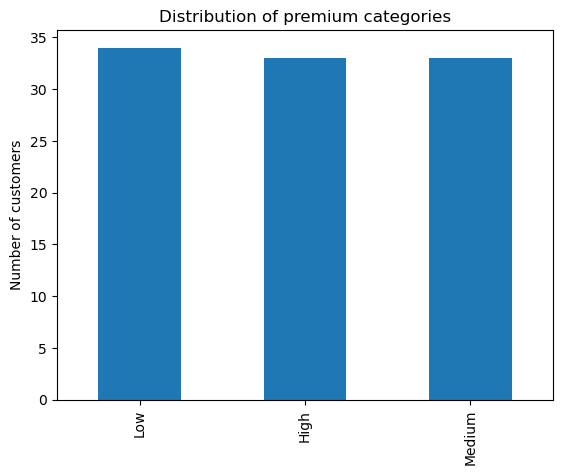

In [9]:
insurance['insurance_premium_category'].value_counts().plot(kind='bar')
plt.title('Distribution of premium categories')
plt.ylabel('Number of customers')
plt.show()

The majority of policyholders fell within the high and medium  premium category

In [10]:
insurance.groupby('insurance_premium_category')['age'].mean()

insurance_premium_category
High      58.484848
Low       37.970588
Medium    45.363636
Name: age, dtype: float64

customers classified under high premiums tended to be older than those in other categories

In [11]:
insurance.groupby('insurance_premium_category')['weight'].mean()

insurance_premium_category
High      94.736364
Low       77.344118
Medium    79.800000
Name: weight, dtype: float64

Higher premium categories appeared to be associated with higher average weight

In [12]:
insurance.groupby('insurance_premium_category')['income_lpa'].mean()

insurance_premium_category
High      14.204545
Low       23.558796
Medium    17.282151
Name: income_lpa, dtype: float64

Average income varied across premium categories, suggesting income may influence insurance purchasing behaviour

In [13]:
pd. crosstab(insurance['smoker'], insurance['insurance_premium_category'])

insurance_premium_category,High,Low,Medium
smoker,,,
False,9,30,18
True,24,4,15


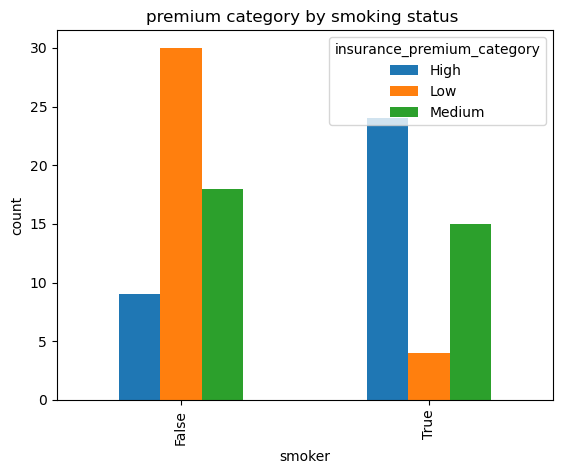

In [14]:
pd. crosstab(insurance['smoker'], insurance['insurance_premium_category']).plot(kind='bar')
plt.title('premium category by smoking status ')
plt.ylabel('count')
plt.show()

The analysis revealed a clear relationship between smoking status and insurance premium clasification.
Most non smokers were classified under the premium category while smokers were predominantly classified under the high premium category
This finding suggests that smoking is an important risk factor in underwriting decisions,leading insurers to assign higher premiums to assign higher
premiums to individuals with greater health related risk.

In [15]:
pd. crosstab(insurance['occupation'], insurance['insurance_premium_category'])

insurance_premium_category,High,Low,Medium
occupation,,,
business_owner,3,6,2
freelancer,3,5,3
government_job,0,11,3
private_job,1,2,8
retired,18,0,8
student,1,5,6
unemployed,7,5,3


In [16]:
occupation_premium=pd.crosstab(insurance['occupation'],
                               insurance['insurance_premium_category'])
occupation_premium

insurance_premium_category,High,Low,Medium
occupation,,,
business_owner,3,6,2
freelancer,3,5,3
government_job,0,11,3
private_job,1,2,8
retired,18,0,8
student,1,5,6
unemployed,7,5,3


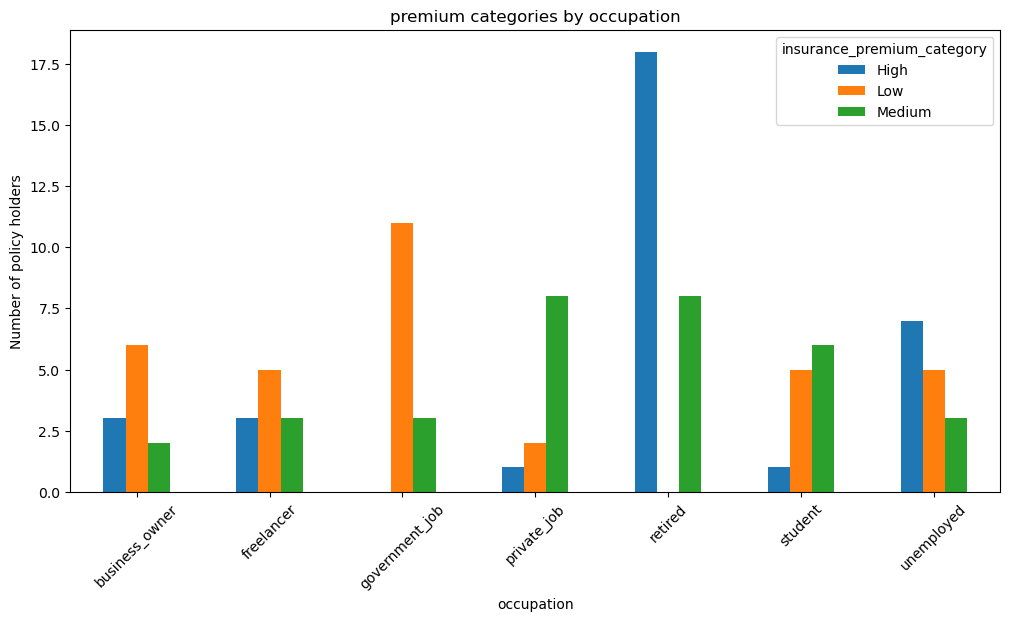

In [17]:
occupation_premium.plot(kind='bar',figsize=(12,6))
plt.title('premium categories by occupation')
plt.xlabel('occupation')
plt.ylabel('Number of policy holders')
plt.xticks(rotation=45)
plt.show()

In [18]:
city_premium=pd.crosstab(insurance['city'],
                               insurance['insurance_premium_category'])
city_premium

insurance_premium_category,High,Low,Medium
city,,,
Bangalore,1,3,0
Chandigarh,4,2,3
Chennai,0,4,3
Delhi,0,4,4
Gaya,1,0,1
Hyderabad,0,4,2
Indore,3,5,1
Jaipur,6,1,2
Jalandhar,7,0,2


In [19]:
pd. crosstab(insurance['city'], insurance['insurance_premium_category'])

insurance_premium_category,High,Low,Medium
city,,,
Bangalore,1,3,0
Chandigarh,4,2,3
Chennai,0,4,3
Delhi,0,4,4
Gaya,1,0,1
Hyderabad,0,4,2
Indore,3,5,1
Jaipur,6,1,2
Jalandhar,7,0,2


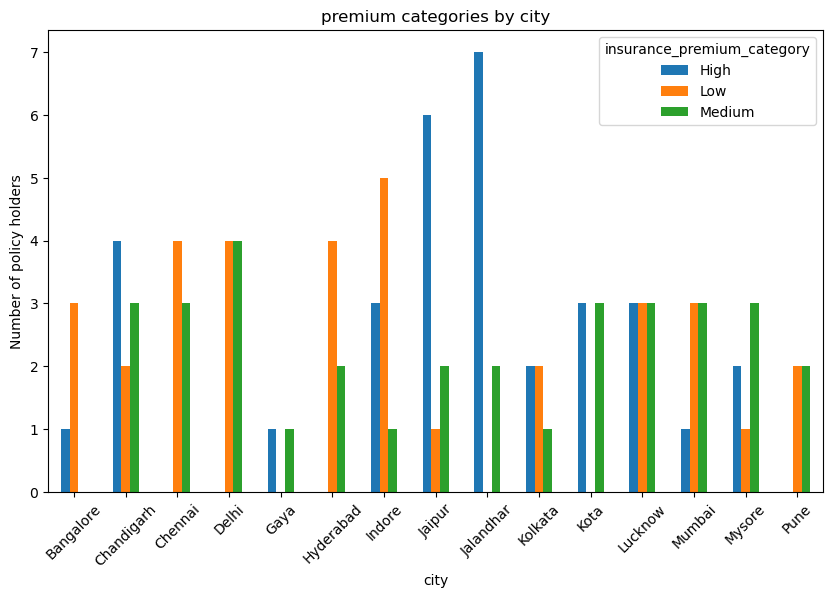

In [20]:
city_premium.plot(kind='bar',figsize=(10,6))
plt.title('premium categories by city')
plt.xlabel('city')
plt.ylabel('Number of policy holders')
plt.xticks(rotation=45)
plt.show()

In [21]:
insurance. groupby('insurance_premium_category')['age'].agg(['mean','min','max'])

,mean,min,max
insurance_premium_category,,,
High,58.484848,24,75
Low,37.970588,18,59
Medium,45.363636,18,73


In [22]:
insurance.columns = insurance.columns. str .strip()

In [23]:
insurance.columns.tolist()

['age',
 'weight',
 'height',
 'income_lpa',
 'smoker',
 'city',
 'occupation',
 'insurance_premium_category']

In [24]:
insurance. groupby('insurance_premium_category')['weight'].agg(['mean','min','max'])

,mean,min,max
insurance_premium_category,,,
High,94.736364,54.5,119.8
Low,77.344118,51.4,119.8
Medium,79.800000,51.1,116.7


In [25]:
insurance. groupby('insurance_premium_category')['income_lpa'].agg(['mean','min','max'])

,mean,min,max
insurance_premium_category,,,
High,14.204545,0.57,50.00
Low,23.558796,0.68,45.07
Medium,17.282151,0.53,50.00


In [26]:
insurance. groupby('insurance_premium_category')['height'].agg(['mean','min','max'])

,mean,min,max
insurance_premium_category,,,
High,1.698182,1.50,1.85
Low,1.739118,1.54,1.89
Medium,1.701515,1.53,1.90


In [27]:
insurance.groupby('insurance_premium_category').agg({'age':'mean','weight':'mean','income_lpa':'mean'}).round(2)

,age,weight,income_lpa
insurance_premium_category,,,
High,58.48,94.74,14.20
Low,37.97,77.34,23.56
Medium,45.36,79.80,17.28


Smoking status was strongly associated with premium classification with smokers moore frequently represented in the high premium category
The high premium category had the hiighest average weight, suggesting weight may be an underwriting factor.
Income alone does not explain premium classification, the low premium category had the highestaverage income.
Premium categorization appears to be more closely linked to risk related characteristics than to earning capacity.

In [28]:
insurance['smoker_numeric']=insurance['smoker'].astype(int)

In [29]:
insurance[['age','weight','income_lpa','smoker_numeric']].corr()

,age,weight,income_lpa,smoker_numeric
age,1.000000,0.033913,-0.163108,0.042993
weight,0.033913,1.000000,-0.113350,0.014156
income_lpa,-0.163108,-0.113350,1.000000,0.023104
smoker_numeric,0.042993,0.014156,0.023104,1.000000


The results indicate generally weak relationships among the variables, with all correlation coefficients close to zero.
Smoking status showed minimal correlation with age,weight and income suggesting that its influenceon premium
classification may operate independently of these demographic characteristics.
The findings indicate that insurance premium classification is likely influenced by a combination of factors rather than a single
dominant predictor.

In [30]:
insurance['insurance_premium_category'].value_counts()

Low       34
High      33
Medium    33
Name: insurance_premium_category, dtype: int64

In [45]:
from sklearn.preprocessing import LabelEncoder
insurance_ml = insurance.copy()
le = LabelEncoder()
le_city = LabelEncoder()
le_occ = LabelEncoder()
insurance_ml['city'] = le_city.fit_transform(insurance_ml['city'])
insurance_ml['occupation'] = le_occ.fit_transform(insurance_ml['occupation'])
insurance_ml['insurance_premium_category']=le.fit_transform(insurance_ml['insurance_premium_category'])



In [46]:
insurance_ml[['city','occupation']].head

<bound method NDFrame.head of     city  occupation
0      7           4
1      2           1
2      6           1
3     12           5
4      6           4
..   ...         ...
95     6           0
96     3           3
97     5           1
98     9           0
99     0           2

[100 rows x 2 columns]>

In [47]:
x=insurance_ml[['age','weight','height','income_lpa','smoker_numeric','city','occupation']]
y=insurance_ml['insurance_premium_category']

In [48]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(
x,
y,
test_size=0.2,
random_state=42)

In [49]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [50]:
from sklearn.metrics import accuracy_score
predictions=model.predict(x_test)
accuracy_score(y_test, predictions)

0.65

A decision tree classifier was developed to predict insurance premium categories using demographic and lifestylevariables.
The model achhieved an accuracy of 65% on the test dataset, indicating a moderate ability to classify policyholders into the 
correct premium category

In [52]:
import pandas as pd

In [54]:
print(type(pd))

<class 'module'>


In [59]:
import pandas as pd
importance = pd . DataFrame({'Feature': x.columns,'Importance': 
                             model.feature_importances_})
importance=importance.sort_values(by='Importance',
ascending=False)
print(importance)

          Feature  Importance
0             age    0.324703
1          weight    0.281949
4  smoker_numeric    0.142936
5            city    0.111658
2          height    0.088018
3      income_lpa    0.035970
6      occupation    0.014766


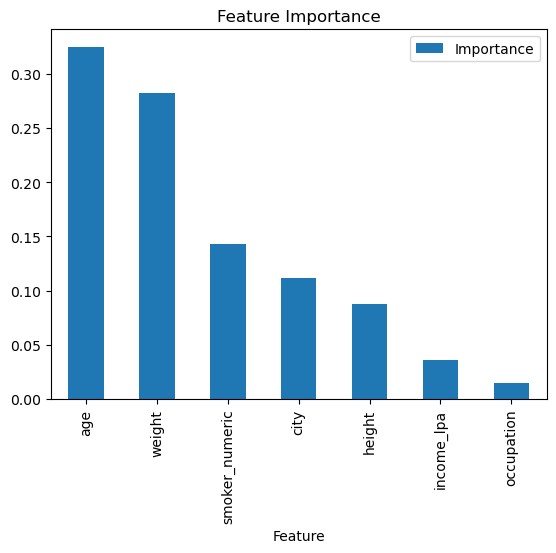

In [60]:
importance.plot(
x='Feature',
y='Importance',
kind='bar'
)
plt.title('Feature Importance')
plt.show()